In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Load Dataset (MNIST-like)
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.MNIST(root="data", train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [5]:
latent_dim = 3

In [6]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim=28*28, latent_dim=128):
        super(VariationalAutoencoder, self).__init__()

        # Encoder
        self.encoder_fc1 = nn.Linear(input_dim, 512)
        self.encoder_fc2 = nn.Linear(512, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_var = nn.Linear(256, latent_dim)

        # Decoder
        self.decoder_fc1 = nn.Linear(latent_dim, 256)
        self.decoder_fc2 = nn.Linear(256, 512)
        self.output_layer = nn.Linear(512, input_dim)

    def encode(self, x):
        h1 = F.relu(self.encoder_fc1(x))
        h2 = F.relu(self.encoder_fc2(h1))
        mu = self.fc_mu(h2)
        logvar = self.fc_var(h2)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h1 = F.relu(self.decoder_fc1(z))
        h2 = F.relu(self.decoder_fc2(h1))
        return torch.sigmoid(self.output_layer(h2))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [7]:
def vae_loss(reconstructed, original, mu, logvar):
    BCE = F.binary_cross_entropy(reconstructed, original, reduction='sum') / original.size(0)
    KLD = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return BCE + KLD, BCE.item(), KLD.item()

In [8]:
# Initialize Model
latent_dim = 128
vae = VariationalAutoencoder(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Training Loop
num_epochs = 300
recon_losses, kl_losses, total_losses = [], [], []

for epoch in range(num_epochs):
    epoch_recon, epoch_kl = 0, 0
    vae.train()
    for images, _ in dataloader:
        images = images.view(images.size(0), -1).to(device)
        reconstructed, mu, logvar = vae(images)

        loss, recon_loss, kl_loss = vae_loss(reconstructed, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_recon += recon_loss
        epoch_kl += kl_loss

    avg_recon = epoch_recon / len(dataloader)
    avg_kl = epoch_kl / len(dataloader)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)
    total_losses.append(avg_recon + avg_kl)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Total: {avg_recon + avg_kl:.4f}, Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}")

print("Training complete!")

Epoch [1/300] - Total: 186.1010, Recon: 178.7160, KL: 7.3850
Epoch [2/300] - Total: 138.8298, Recon: 124.4172, KL: 14.4126
Epoch [3/300] - Total: 124.2260, Recon: 108.9034, KL: 15.3226
Epoch [4/300] - Total: 116.7380, Recon: 100.3681, KL: 16.3700
Epoch [5/300] - Total: 112.8603, Recon: 95.8529, KL: 17.0074
Epoch [6/300] - Total: 110.6770, Recon: 93.2022, KL: 17.4748
Epoch [7/300] - Total: 109.1267, Recon: 91.3869, KL: 17.7398
Epoch [8/300] - Total: 107.9402, Recon: 89.9987, KL: 17.9414
Epoch [9/300] - Total: 107.0273, Recon: 88.8960, KL: 18.1313
Epoch [10/300] - Total: 106.1623, Recon: 87.8936, KL: 18.2687
Epoch [11/300] - Total: 105.2813, Recon: 86.8428, KL: 18.4385
Epoch [12/300] - Total: 104.6806, Recon: 86.0915, KL: 18.5891
Epoch [13/300] - Total: 104.1020, Recon: 85.4015, KL: 18.7006
Epoch [14/300] - Total: 103.4326, Recon: 84.6314, KL: 18.8012
Epoch [15/300] - Total: 102.8966, Recon: 83.9745, KL: 18.9220
Epoch [16/300] - Total: 102.4209, Recon: 83.4080, KL: 19.0130
Epoch [17/300]

# Variational Autoencoder (VAE) vs. Autoencoder (AE)


## 🔍 Qualitative Comparison: AE vs. VAE

| Feature | Autoencoder (AE) | Variational Autoencoder (VAE) |
|--------|------------------|-------------------------------|
| **Latent Representation** | Deterministic | Probabilistic (mean and variance) |
| **Reconstruction Quality** | Sharp and accurate | Slightly blurrier due to stochastic sampling |
| **Latent Space Structure** | Arbitrary, not continuous | Enforced to follow a unit Gaussian distribution |
| **New Sample Generation** | Difficult or unmeaningful | Easy and meaningful (sample from `N(0, I)`) |
| **Interpolation** | Unstructured / discontinuous | Smooth transitions between digits |
| **Training Stability** | Faster convergence | Slower convergence due to KL divergence term |

## Conclusion

While AEs perform better at raw reconstruction, VAEs offer significant advantages in latent space organization, generation, and interpolation. For tasks involving data synthesis, structured latent representations, or probabilistic reasoning, **VAEs are the superior choice**.



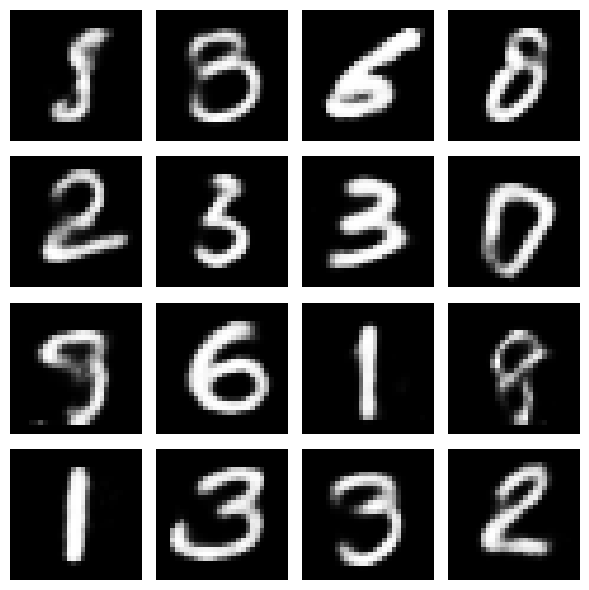

In [9]:
# Generate New Samples
vae.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated = vae.decode(z).cpu().view(-1, 1, 28, 28)

# Plot Generated Samples
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].squeeze(), cmap="gray")
    ax.axis('off')
plt.tight_layout()
plt.show()

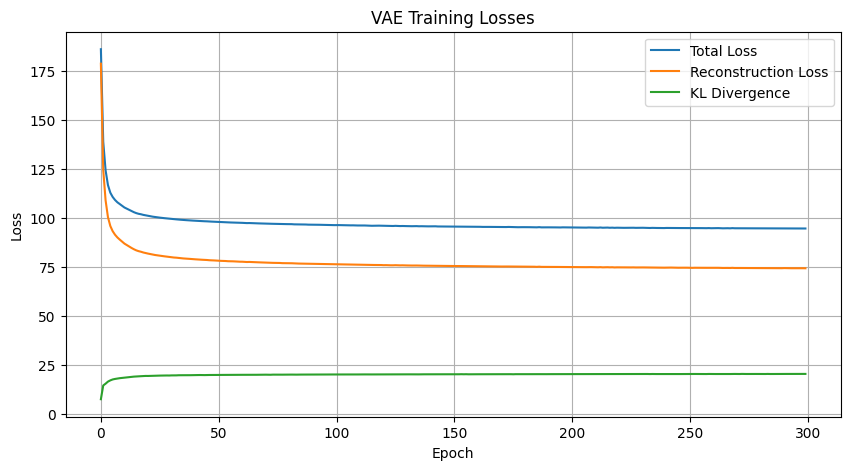

In [10]:
# Plot Training Losses
plt.figure(figsize=(10, 5))
plt.plot(total_losses, label='Total Loss')
plt.plot(recon_losses, label='Reconstruction Loss')
plt.plot(kl_losses, label='KL Divergence')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE Training Losses")
plt.grid(True)
plt.show()

At the start of training, all components of the loss decrease or increase rapidly. This is expected, as the model initially learns to reconstruct the input data while also shaping the latent space. Over time, the curves begin to flatten, indicating that the model is learning at a slower rate and approaching convergence.

 The model appears to have learned both to reconstruct inputs and to maintain a meaningful latent space, so further training may not be necessary

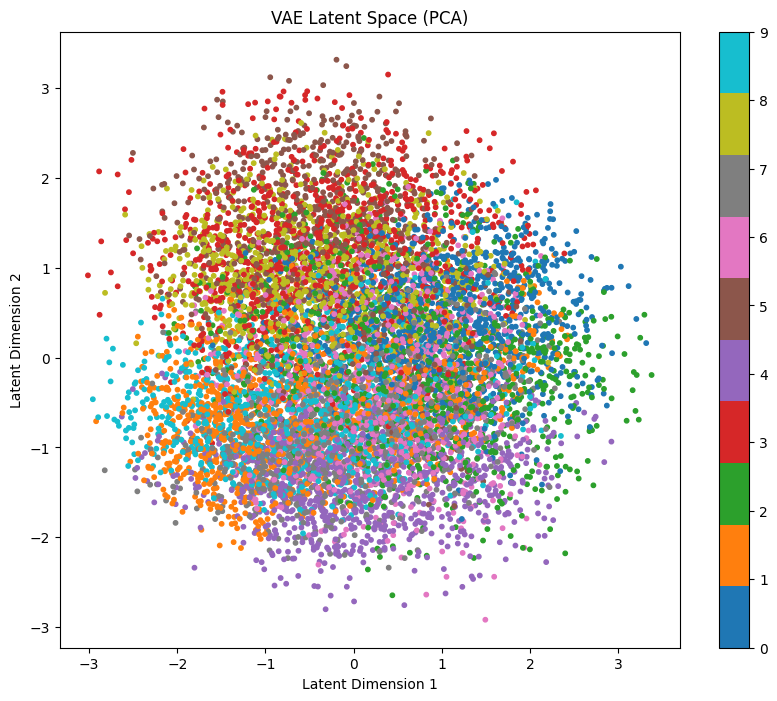

In [12]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np

# Load the test set
test_dataset = datasets.MNIST(root='data', train=False, transform=transforms.ToTensor(), download=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

# Encode the test set images to latent space
vae.eval()
latent_representations = []
labels = []

with torch.no_grad():
    for images, target in test_loader:
        images = images.view(images.size(0), -1).to(device)
        mu, _ = vae.encode(images)  # Get mean (mu) for each sample in the batch
        latent_representations.append(mu.cpu().numpy())  # Store latent variables
        labels.append(target.numpy())  # Store corresponding labels

# Flatten the list of latent representations and labels
latent_representations = np.concatenate(latent_representations, axis=0)
labels = np.concatenate(labels, axis=0)

# Reduce to 2D using PCA or t-SNE
pca = PCA(n_components=2)
latent_2d_pca = pca.fit_transform(latent_representations)

# Visualize the 2D latent space
plt.figure(figsize=(10, 8))
plt.scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], c=labels, cmap='tab10', s=10)
plt.colorbar()
plt.title("VAE Latent Space (PCA)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.show()
